In [1]:
import numpy as np
from scipy.signal import cont2discrete

from config.matrizes_config import matrizes
from S_MPC import matriz_S
from Yr_MPC import alvo
from Y0_MPC_V2 import y_0
import casadi as cs
from config.config import values
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### planta

In [2]:
def mu(S, params):
    # Tx. específica de crescimento

    if not np.isfinite(S):
        raise FloatingPointError(f"S virou NaN/Inf dentro de mu: S={S}")

    if S <= -params["Ks"]:
        raise FloatingPointError(
            f"S chegou perto da singularidade de Monod: S={S}, Ks={params['Ks']}"
        )
    
    mu = (params["Mi_m"]*S)/(params["Ks"] + S)
    return mu


def bioreactor_model(states, u, params):
    X, S = states
    D, Sf = u

    # X = max(X, 0.0)
    # S = max(S, 0.0)

    # eqs.
    dXdt = mu(S, params) * X - D * X
    dSdt = D * (Sf - S) - (mu(S, params) * X)/params["Y"]

    return [dXdt, dSdt]

### constantes

In [3]:
Ts = 1.5 # h             # tempo de amostragem -> 0.25*15 approx 15h
N = 12                 # horizonte do modelo
P = 17                 # horizonte de predição
M = 5                  # horizonte de controle
m = 2
r = 2

In [4]:
Sdyn = matriz_S(m, r, M, P, N, Ts=Ts)

In [5]:
# indica em quantos passos a ref. aproxima de ysp
# se for pequeno -> alfa^j -> reduza rapido -> indica precisa chegar no alvo praticamente agora -> tende a bater nos limites de controle
# se grande -> anda devagar até o ysp -> u menos agressivo
tau_ref_S = 5 # h #tempo que desejo p/ a ref se aproximar do ysp
tau_ref_X = 5
alfa = np.exp(-Ts / np.array([tau_ref_X, tau_ref_S])) # p/ relacionar o tempo de aproximação desejado com o intervalo que observo/atualizo o controlador
# alfa = np.array([1,1])
ysp = np.array([0.3066, 0.2333])

# estado/planta atual
y_atual = np.array([0.286, 0.21])      
u_ant = np.array([0.3, 0.8])  # u inicial

# desisto: ajuste p/ desvio
# ===========================
y_bar = np.array([values["X_bar"], values["S_bar"]])
u_bar = np.array([values["D"], values["Sf"]])
# =======================

# "primeira" previsão anterior
y_hat_anterior = y_atual.copy()

erro_modelo = y_atual - y_hat_anterior # começa em 0
N_sim = 500

# históricos
# inicialmente cenário de regime
hist_du = np.zeros(r * (N - 1))
dU_ant = np.zeros(r * M)
dU_ant_par = np.zeros(r)
# hist_u = np.zeros(r * (N - 1)) hist_u = [D0, Sf0, 0, 0, 0, 0, 0, 0] -> pode gerar “transiente fantasma” nas prev. futuras
# hist_u = np.tile(u_ant, N - 1) # hist_u = [D0, Sf0, D0, Sf0, D0, Sf0, D0, Sf0]

# desisto: ajuste p/ desvio
# ===========================
hist_u = np.tile(u_ant - u_bar, N - 1)
# =======================


# matrizes
I = np.kron(np.ones((P, 1)), np.eye(m))

# logs
Y_log = []
U_log = []
DU_log = []
Yhat_log = []
Y_nL_log = []


In [6]:
#  Q e R
# Q = np.diag([1.0, 1.0])      # 2x2
# R = np.diag([1.0, 1.0])     # 2x2
# resultado: X ficou ok, mas o S mau. mt ação de controle tbm oh t_t okook

Q_ = np.diag([1, 1])
R_ = np.diag([10, 1])

# Nome da pasta: mpc_Q_1_1_R_1_1 (ou conforme os valores de Q e R)
def format_diag(M):
    return "_".join(f"{v:g}" for v in np.diag(M))

dir_name = f"mpc_Q_{format_diag(Q_)}_R_{format_diag(R_)}"

Qbar = np.kron(np.eye(P), Q_) # 2P x 2P
Rbar = np.kron(np.eye(M), R_) # 2M x 2M

Wp = 1.0 * Rbar
W1 = 10.0 * R_
# print(Qbar)
# print(Rbar)

### otimizador

In [7]:
opti = cs.Opti()

dU = opti.variable(r*M, 1) # variável de decisão

# param. -> muda a cada exec
Y0_corrigido = opti.parameter(m*P, 1)
Yr = opti.parameter(m*P, 1)
u_ant_par = opti.parameter(r, 1)
dU_ref = opti.parameter(r*M, 1)
du_ant_par = opti.parameter(r, 1)

# matrizes constantes
S = cs.DM(Sdyn)
Q = cs.DM(Qbar)
R = cs.DM(Rbar)
Wp = cs.DM(Wp) # pesos
W1 = cs.DM(W1) 

Ypred = Y0_corrigido + S @ dU

erro = Yr - Ypred

du0 = dU[0:r]

J = (erro.T @ Q @ erro + dU.T @ R @ dU
     + (dU - dU_ref).T @ Wp @ (dU - dU_ref)
    + (du0 - du_ant_par).T @ W1 @ (du0 - du_ant_par)
    )


opti.minimize(J)

# restrição em u absoluto: <= u_prev + du <=
T = np.kron(np.tril(np.ones((M, M))), np.eye(r)) # approx. matrix inf. ident.
T = cs.DM(T)

Uprev = cs.repmat(u_ant_par, M, 1) # matriz repetindo u_ant
Ufut = Uprev + T @ dU

du_min = cs.DM([-0.01, -0.03])
du_max = cs.DM([ 0.01,  0.03])

u_min = cs.DM([0.245, 0.65])
u_max = cs.DM([0.455, 1.35])

# restrição de y 
y_min = cs.DM([0.276, 0.187])
y_max = cs.DM([0.337, 0.279])

opti.subject_to([
    cs.repmat(u_min, M, 1) <= Ufut, 
	Ufut <= cs.repmat(u_max, M, 1),
    cs.repmat(y_min, P, 1) <= Ypred,
    Ypred <= cs.repmat(y_max, P, 1),
    cs.repmat(du_min, M, 1) <= dU,
    dU <= cs.repmat(du_max, M, 1)
])

opti.solver("ipopt", {
    "print_time": False,
    "ipopt": {"print_level": False}
})

K = opti.to_function(
    "K",
    [Y0_corrigido, Yr, u_ant_par, dU_ref, du_ant_par],
    [dU[0:r], Ypred[0:m], dU]
)


In [8]:
def check_finite(nome, x, k):
    x = np.asarray(x, dtype=float)
    if not np.all(np.isfinite(x)):
        raise FloatingPointError(f"k={k}: {nome} virou NaN/Inf -> {x}")

In [9]:

for k in range(N_sim):

    # medido da planta
    y_k = y_atual.copy()

    # calcular previsão livre
    # Y0 = y_0(P, N, Sdyn, hist_du, hist_u)
    # Y0 = Y0.reshape(m * P, 1)

    # tbm desisto: ajuste p/ desvio
    # ===========================
    Y0_dev = y_0(P, N, Sdyn, hist_du, hist_u)
    Y0_dev = Y0_dev.reshape(m * P, 1)

    Ybar_ext = np.tile(y_bar, P).reshape(m * P, 1)

    Y0 = Ybar_ext + Y0_dev
    # ===========================
    check_finite("Y0", Y0, k)

    # corrigir previsão livre
    erro_modelo = (y_k - y_hat_anterior).reshape(m, 1)

    Y0_corrigido = Y0 + I @ erro_modelo
    check_finite("Y0_corrigido", Y0_corrigido, k)

    # referência futura
    Yr = alvo(alfa, y_k, ysp, m, P)
    # Yr = np.tile(ysp, P)
    Yr = Yr.reshape(m* P, 1)
    check_finite("Yr", Yr, k)
    
    dU_ref = np.zeros((r*M, 1))
    dU_ant = np.array(dU_ant, dtype=float).reshape(r*M, 1)
    
    dU_ref[0:r*(M-1), 0] = dU_ant[r:r*M, 0]
    dU_ref[r*(M-1):r*M, 0] = 0.0

    # solver -> delta_u(k) e y_hat(k+1)
    du_k, y_hat_next, dU_ant = K(
        Y0_corrigido,
        Yr,
        u_ant.reshape(r, 1),
        dU_ref,
        dU_ant_par
    )

    du_k = np.array(du_k).flatten()
    y_hat_next = np.array(y_hat_next).flatten()

    # incremento no último u
    u_k = u_ant + du_k

    check_finite("du_k", du_k, k)
    check_finite("y_hat_next", y_hat_next, k)
    check_finite("u_k", u_k, k)

    # simular planta não linear de k até k+1
    sol = solve_ivp(
        fun=lambda t, y: bioreactor_model(y, u_k, values),
        t_span=(0, Ts),
        y0=y_atual,
        method="RK45",
        # max_step = Ts/100
    )

    y_next = sol.y[:, -1]

    check_finite("y_next", y_next, k)

    if y_next[1] < 0:
        raise FloatingPointError(f"k={k}: substrato S ficou negativo: {y_next}")

    # salvando -> verificar
    Y_log.append(y_k) # modelo não linear
    U_log.append(u_k)
    DU_log.append(du_k)
    Yhat_log.append(y_hat_next) # mpc

    # histórico -> controle mais novo no início e joga os antigos para frente
    hist_du = np.r_[du_k, hist_du[:-r]]
    # hist_u = np.r_[u_k, hist_u[:-r]]
    
    # tbm desisto: ajuste p/ desvio
    # ===========================
    hist_u = np.r_[u_k - u_bar, hist_u[:-r]]

    # atualizar p/ próxima iteração
    u_ant = u_k
    y_atual = y_next
    y_hat_anterior = y_hat_next

print("CHATO DEMAIS")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

CHATO DEMAIS


In [10]:
from utils.saves import img_save


In [11]:
Y_log = np.array(Y_log)          # modelo não linear
U_log = np.array(U_log)          # controle
Yhat_log = np.array(Yhat_log)    # previsão MPC

ysp = np.array([0.3066, 0.2333])

t = np.arange(len(Y_log)) * Ts

# ---------------- X ----------------
plt.figure(figsize=(10, 5))
plt.plot(t, Y_log[:, 0], label="X não linear", linewidth=2)
# plt.plot(t, Yhat_log[:, 0], "--", label="X previsto MPC")
plt.axhline(ysp[0], color="r", linestyle="--", linewidth=2,
            label=f"Xsp = {ysp[0]:.4f}")

plt.xlabel("Tempo")
plt.ylabel("X")
plt.title("Biomassa X")
plt.grid(True)
plt.legend()
plt.ylim(0.28,0.33)
img_save("X", dir_name)

# ---------------- S ----------------
plt.figure(figsize=(10, 5))
plt.plot(t, Y_log[:, 1], label="S não linear", linewidth=2)
# plt.plot(t, Yhat_log[:, 1], "--", label="S previsto MPC")
plt.axhline(ysp[1], color="r", linestyle="--", linewidth=2,
            label=f"Ssp = {ysp[1]:.4f}")

plt.xlabel("Tempo")
plt.ylabel("S")
plt.title("Substrato S")
plt.grid(True)
plt.legend()
plt.ylim(0.16,0.25)
img_save("S", dir_name)

# ---------------- D ----------------
plt.figure(figsize=(10, 5))
plt.plot(t, U_log[:, 0], label="D", linewidth=2)

plt.xlabel("Tempo")
plt.ylabel("D")
plt.title("Controle D")
plt.grid(True)
plt.legend()
plt.ylim(0.31,0.38)
img_save("D", dir_name)

# ---------------- Sf ----------------
plt.figure(figsize=(10, 5))
plt.plot(t, U_log[:, 1], label="Sf", linewidth=2)

plt.xlabel("Tempo")
plt.ylabel("Sf")
plt.title("Controle Sf")
plt.grid(True)
plt.legend()
plt.ylim(0.8,1.1)
img_save("Sf", dir_name)

Imagem salva em: c:\Users\ander\Desktop\Sistemas inteligentes\imgs\mpc_Q_1_1_R_10_1\X.png
Imagem salva em: c:\Users\ander\Desktop\Sistemas inteligentes\imgs\mpc_Q_1_1_R_10_1\S.png
Imagem salva em: c:\Users\ander\Desktop\Sistemas inteligentes\imgs\mpc_Q_1_1_R_10_1\D.png
Imagem salva em: c:\Users\ander\Desktop\Sistemas inteligentes\imgs\mpc_Q_1_1_R_10_1\Sf.png


min Δu: [-0.00081762 -0.00278252]
max Δu: [0.01284798 0.05659258]
corr ΔD[k], ΔD[k+1]: 0.08017001918945516
corr ΔSf[k], ΔSf[k+1]: -0.19693133729837706


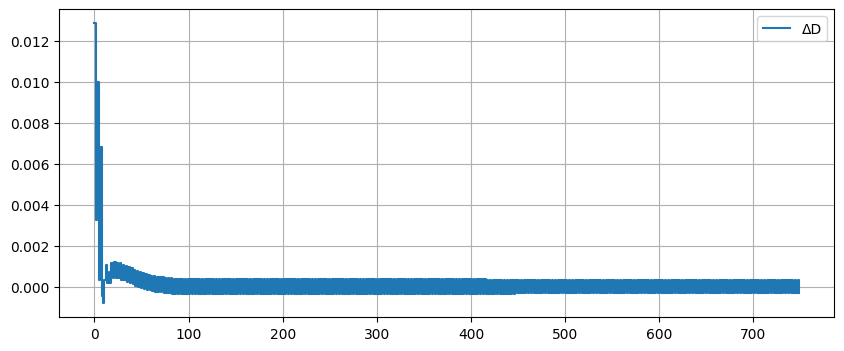

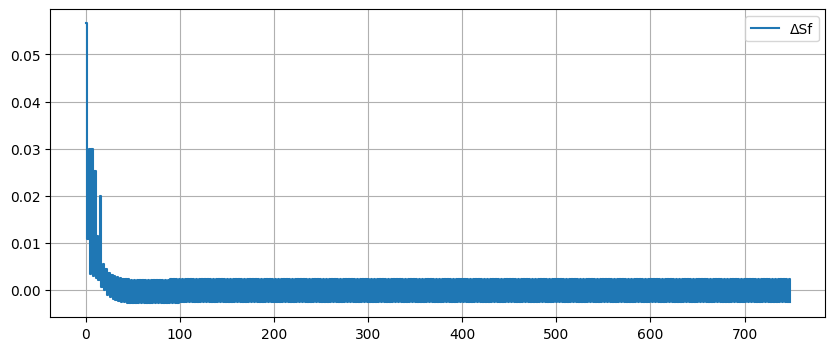

In [12]:
DU_log_arr = np.array(DU_log)

plt.figure(figsize=(10, 4))
plt.step(t, DU_log_arr[:, 0], where="post", label="ΔD")
plt.grid(True)
plt.legend()

plt.figure(figsize=(10, 4))
plt.step(t, DU_log_arr[:, 1], where="post", label="ΔSf")
plt.grid(True)
plt.legend()

DU = np.array(DU_log)

print("min Δu:", DU.min(axis=0))
print("max Δu:", DU.max(axis=0))

print("corr ΔD[k], ΔD[k+1]:", np.corrcoef(DU[:-1, 0], DU[1:, 0])[0, 1])
print("corr ΔSf[k], ΔSf[k+1]:", np.corrcoef(DU[:-1, 1], DU[1:, 1])[0, 1])